In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
bd= pd.read_csv('datafixed_bolide_data.csv') #the index for bolide 1 is 12

In [3]:
b6= bd.iloc[105]

In [4]:
b6['datetime']

'2020-07-17,11:01:13.850616+00:00'

In [5]:
lat= literal_eval(b6['lat_stereo_g17'])
long= literal_eval(b6['lat_stereo_g17'])
alt= literal_eval(b6['alt_stereo_g17'])
energy = literal_eval(b6['energyJoules_stereo_g17'])

In [6]:
def findtheta(lat, long, alt):
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])*0.0175
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom(theta, r=6378137): #r in m
    rad= theta*0.0175
    return r*rad

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
                                    #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))

H=8500 #meters
rho0= 1.225 #kg/m^3
rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3

In [7]:
print (len(lat), len(long), len(alt), len(energy))

135 135 135 135


In [8]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        print(i) #determine the index at which the bolide catastrophically destructs

74


In [9]:
totalmass= 0
totalh= 0 
for i in range (74): 
    deltalat = np.abs(degtom(lat[i+1]-lat[i])) #change in lat converted to meters 
    deltalong = np.abs(degtom(long[i+1]-long[i]))
    deltaalt = (np.abs(alt[i+1]-alt[i]))*1000 #multipled by 1000 to convert to meters
    h= np.sqrt(deltalat**2 + deltalong**2 + deltaalt**2)
    totalh= totalh+h 

    altm = (alt[i]+alt[i+1])*1000
    rho = airrho((1/2)*altm)
    totalmass = totalmass+(h*rho)

In [10]:
rrocky = (3/4)*(totalmass/rockyrho)
rmetal = (3/4)*(totalmass/metalrho)
ricy = (3/4)*(totalmass/icyrho)

print (rrocky, rmetal, ricy) #this unit is METERS 

8.659198689626683e-06 4.040959388492451e-06 4.040959388492451e-05


In [11]:
totalh

746.3084189636186

In [12]:
for i in range(len(alt)-1):
    print (alt[i]-alt[i+1])

0.003094709999999168
0.0031461100000029774
0.00028853000000594875
-0.0007354899999967301
-0.0007501200000064046
-0.0004847599999919794
-1.8800000134433503e-06
-0.0007727200000005041
-0.0007486799999867344
-0.001020250000010492
-0.0007609299999984387
-0.0005115099999954964
0.0005307299999941506
0.0007719999999977745
0.0010394399999995585
-2.069999993636884e-06
-0.0002593199999978424
-0.0002671499999991056
-0.00027393999999958396
2.339999994660502e-06
-0.00027394999999330594
0.00025723999999627267
0.0004985099999998965
0.0015407599999974764
0.001010340000007659
0.0012723099999902843
0.0017599000000103615
0.0002104599999910306
-0.0010913600000037604
-0.0010712899999987258
-0.0013162399999941954
-0.0015027400000064972
-0.0014977399999906993
-0.0015005799999983083
-0.0014716100000100596
-0.0015117899999950168
-0.002101740000000518
-0.0008147199999939403
0.001013309999990497
0.0009942700000067362
0.001020130000000563
0.0023682100000002038
0.0013306099999965681
-0.0002251399999977366
-0.00022

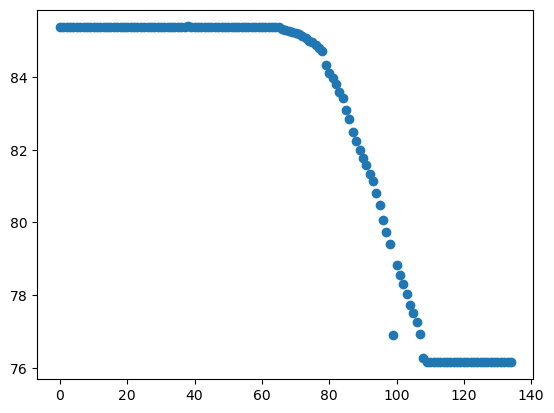

In [13]:
plt.scatter(range(len(alt)), alt)